# From HSC Galaxy Image to ConvNeXt Embedding

This notebook walks through every step of the pipeline that turns a raw Hyper Suprime-Cam (HSC) galaxy image into a fixed-length embedding vector using ConvNeXtV2.

HSC images are **always resized to 22×22 px** before normalisation. The `resize_mode` parameter controls *how* the crop is determined:

```
hsc_image['flux']  (5, 160, 160) float32
      │
      ▼  channel selection  →  (160, 160, 3) float32  [g, r, z]
      │
      ├─── resize_mode="fill" ─────────────────────────────────────────────┐
      │    Otsu threshold → detect galaxy blob → adaptive crop → 22×22     │
      │                                                                     │
      └─── resize_mode="match"  (default) ────────────────────────────────┤
           fixed force_extent=(68,92,68,92) → 29px centre crop → 22×22    │
                                                                            │
      ▼ (both paths rejoin here)                              ◄────────────┘
      percentile normalisation  →  [0, 1] float32
      │
      ▼  channel flip + uint8 cast  →  (22, 22, 3) uint8
      │
      ▼  AutoImageProcessor         →  (1, 3, 224, 224) float32
      │
      ▼  ConvNeXtV2 forward         →  (1, 640, 7, 7) float32
      │
      ▼  .mean(dim=(2, 3))          →  (1, 640) float32  ← embedding
```

We run both modes and compare the resulting embeddings at the end.

## 0. Imports

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn.functional as F
from datasets import load_dataset
from transformers import AutoModel, AutoImageProcessor

from pu.zoom import resize_galaxy_to_fit

/global/homes/a/ashodkh/.conda/envs/my_torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load one HSC image from the dataset

The crossmatched dataset lives on HuggingFace Hub. Each row contains images from multiple surveys for the **same galaxy**. We stream it and take the first row.

In [2]:
HF_DATASET = "Smith42/jwst_hsc_crossmatched"

ds = load_dataset(HF_DATASET, split="train", streaming=True)
row = next(iter(ds))

raw_flux = np.asarray(row["hsc_image"]["flux"], dtype=np.float32)
print(f"raw_flux shape : {raw_flux.shape}   (num_bands, height, width)")
print(f"value range    : [{raw_flux.min():.3f}, {raw_flux.max():.3f}]")

raw_flux shape : (5, 160, 160)   (num_bands, height, width)
value range    : [-0.315, 5.334]


## 2. Channel selection  (shared by both paths)

HSC has 5 bands. We pick g (index 0), r (index 1), z (index 3) and stack them into a `(H, W, 3)` array. This happens before any resizing or normalisation.

After channel selection: (160, 160, 3)


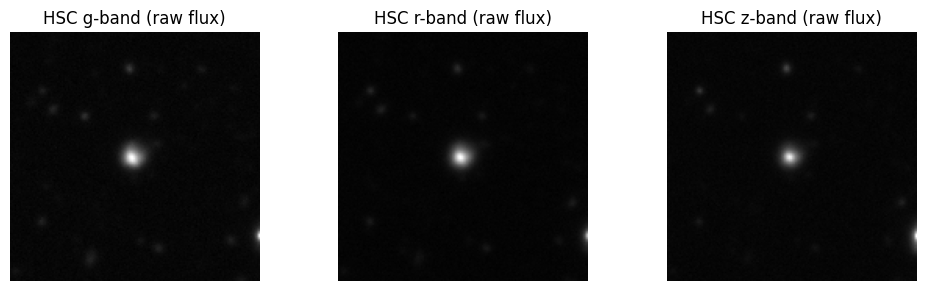

In [3]:
arr = np.stack([raw_flux[0], raw_flux[1], raw_flux[3]], axis=-1)   # (160, 160, 3)
print(f"After channel selection: {arr.shape}")

fig, axs = plt.subplots(1, 3, figsize=(10, 3))
for i, band in enumerate(("g", "r", "z")):
    axs[i].imshow(arr[..., i], cmap="gray", origin="lower")
    axs[i].set_title(f"HSC {band}-band (raw flux)")
    axs[i].axis("off")
plt.tight_layout()
plt.show()

## 3. The resize fork

HSC images are always passed through `resize_galaxy_to_fit` in `flux_to_pil()` (`src/pu/preprocess.py`):

```python
if resize_mode == "fill":
    arr = resize_galaxy_to_fit(arr, target_size=22)
else:  # match  ← default
    arr = resize_galaxy_to_fit(arr, force_extent=(68, 92, 68, 92), target_size=22)
```

The two modes differ only in how the crop window is determined:

| | `fill` | `match` (default) |
|---|---|---|
| Crop size | Detected per-galaxy via Otsu threshold | Fixed — always 29×29 px |
| Behaviour | Adapts to each galaxy's actual angular size | Same crop for every galaxy |
| Risk | Fails silently if no blob found at centre | Ignores actual galaxy size |

### 3a. `resize_mode="fill"` — Otsu-detected crop

`resize_galaxy_to_fit` without `force_extent` runs Otsu thresholding on the r-band, finds the contiguous blob at the image centre, measures its extent, and crops a padded window around it.

Otsu threshold value : 0.1056
Blob size at centre  : 938 px
Detected extent      : (np.int64(63), np.int64(96), np.int64(62), np.int64(95))  (min_row, max_row, min_col, max_col)

fill crop window     : [60:100, 60:100]  (40×40 px)
fill  mode output    : (22, 22, 3)


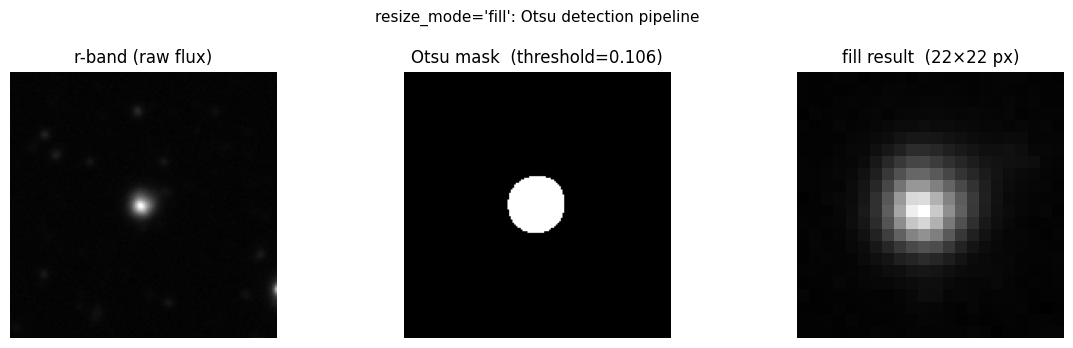

In [4]:
from pu.zoom import otsu_threshold, find_center_blob_info

TARGET_SIZE   = 22
PADDING_RATIO = 0.1

# Run Otsu detection on the r-band to see what "fill" mode detects
mask_fill, thresh = otsu_threshold(arr[..., 1])
blob_size, fill_extent = find_center_blob_info(mask_fill)
print(f"Otsu threshold value : {thresh:.4f}")
print(f"Blob size at centre  : {blob_size} px")
print(f"Detected extent      : {fill_extent}  (min_row, max_row, min_col, max_col)")

if fill_extent is not None:
    min_r, max_r, min_c, max_c = fill_extent
    fill_gal_len = max(max_r - min_r + 1, max_c - min_c + 1)
    fill_pad     = int(fill_gal_len * PADDING_RATIO)
    fill_crop    = fill_gal_len + 2 * fill_pad
    H, W, _      = arr.shape
    ch, cw       = H // 2, W // 2
    fill_r0 = max(0, ch - fill_crop // 2);  fill_r1 = min(H, ch + fill_crop // 2)
    fill_c0 = max(0, cw - fill_crop // 2);  fill_c1 = min(W, cw + fill_crop // 2)
    print(f"\nfill crop window     : [{fill_r0}:{fill_r1}, {fill_c0}:{fill_c1}]  "
          f"({fill_r1-fill_r0}×{fill_c1-fill_c0} px)")

arr_fill = resize_galaxy_to_fit(arr, target_size=TARGET_SIZE)
print(f"fill  mode output    : {arr_fill.shape}")

fig, axs = plt.subplots(1, 3, figsize=(12, 3.5))
axs[0].imshow(arr[..., 1], cmap="gray", origin="lower")
axs[0].set_title("r-band (raw flux)")
axs[0].axis("off")
axs[1].imshow(mask_fill, cmap="gray", origin="lower")
axs[1].set_title(f"Otsu mask  (threshold={thresh:.3f})")
axs[1].axis("off")
axs[2].imshow(arr_fill[..., 1], cmap="gray", origin="lower")
axs[2].set_title(f"fill result  ({arr_fill.shape[0]}×{arr_fill.shape[1]} px)")
axs[2].axis("off")
plt.suptitle("resize_mode='fill': Otsu detection pipeline", fontsize=11)
plt.tight_layout()
plt.show()

### 3b. `resize_mode="match"` — fixed crop

`resize_galaxy_to_fit` with `force_extent=(68, 92, 68, 92)` skips Otsu detection entirely. The extent is used only to compute a crop *size*:

```
galaxy_length = max(92−68+1, 92−68+1) = 25 px
pad           = int(25 × 0.1)         =  2 px
crop window   = 25 + 2×2              = 29 px  (centred on the image)
```

The values `(68, 92, 68, 92)` encode the typical JWST galaxy extent in JWST pixel coordinates, so the resulting HSC crop covers approximately the same angular footprint (~1 arcsec) as a JWST image. Every HSC galaxy gets this same 29 px window regardless of its actual size.

In [5]:
FORCE_EXTENT = (68, 92, 68, 92)

min_row, max_row, min_col, max_col = FORCE_EXTENT
match_gal_len = max(max_row - min_row + 1, max_col - min_col + 1)   # 25
match_pad     = int(match_gal_len * PADDING_RATIO)                   # 2
match_crop    = match_gal_len + 2 * match_pad                        # 29

H, W, _ = arr.shape
ch, cw   = H // 2, W // 2
match_r0 = max(0, ch - match_crop // 2);  match_r1 = min(H, ch + match_crop // 2)
match_c0 = max(0, cw - match_crop // 2);  match_c1 = min(W, cw + match_crop // 2)

print(f"match galaxy_length  : {match_gal_len} px  (always the same)")
print(f"match crop window    : [{match_r0}:{match_r1}, {match_c0}:{match_c1}]  "
      f"({match_r1-match_r0}×{match_c1-match_c0} px)")

arr_match = resize_galaxy_to_fit(arr, force_extent=FORCE_EXTENT, target_size=TARGET_SIZE)
print(f"match mode output    : {arr_match.shape}")

match galaxy_length  : 25 px  (always the same)
match crop window    : [66:94, 66:94]  (28×28 px)
match mode output    : (22, 22, 3)


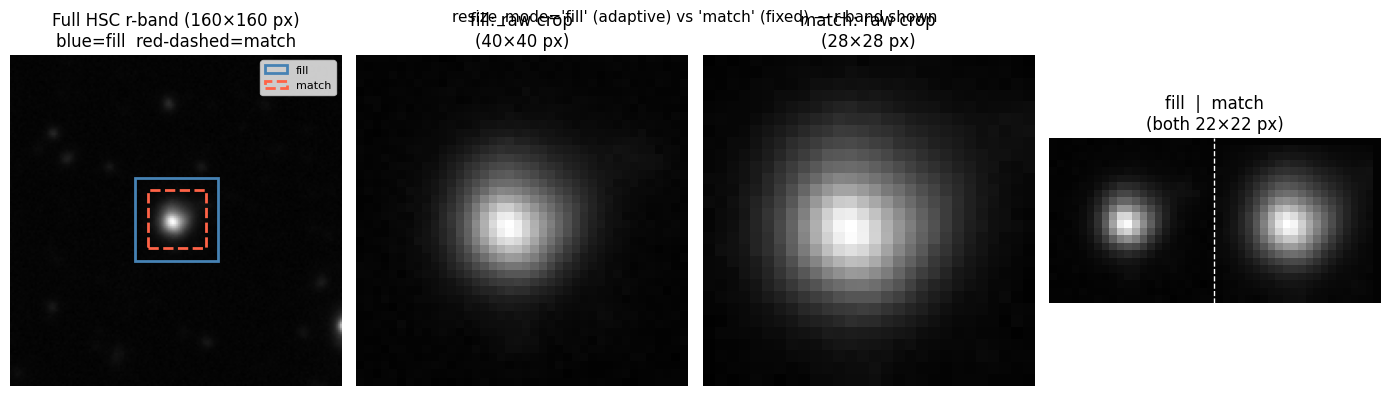

In [6]:
# Side-by-side comparison: full image with both crop boxes, then the two results
fig, axs = plt.subplots(1, 4, figsize=(14, 4))

# Full image with both crop boxes overlaid
axs[0].imshow(arr[..., 1], cmap="gray", origin="lower")
if fill_extent is not None:
    axs[0].add_patch(patches.Rectangle(
        (fill_c0, fill_r0), fill_c1 - fill_c0, fill_r1 - fill_r0,
        linewidth=2, edgecolor="steelblue", facecolor="none", label="fill"
    ))
axs[0].add_patch(patches.Rectangle(
    (match_c0, match_r0), match_c1 - match_c0, match_r1 - match_r0,
    linewidth=2, edgecolor="tomato", facecolor="none", label="match", linestyle="--"
))
axs[0].legend(fontsize=8, loc="upper right")
axs[0].set_title(f"Full HSC r-band ({H}×{W} px)\nblue=fill  red-dashed=match")
axs[0].axis("off")

# fill crop (raw, before zoom)
if fill_extent is not None:
    axs[1].imshow(arr[fill_r0:fill_r1, fill_c0:fill_c1, 1], cmap="gray", origin="lower")
    axs[1].set_title(f"fill: raw crop\n({fill_r1-fill_r0}×{fill_c1-fill_c0} px)")
else:
    axs[1].text(0.5, 0.5, "no blob\ndetected", ha="center", va="center",
                transform=axs[1].transAxes, fontsize=10)
    axs[1].set_title("fill: raw crop\n(detection failed)")
axs[1].axis("off")

# match crop (raw, before zoom)
axs[2].imshow(arr[match_r0:match_r1, match_c0:match_c1, 1], cmap="gray", origin="lower")
axs[2].set_title(f"match: raw crop\n({match_r1-match_r0}×{match_c1-match_c0} px)")
axs[2].axis("off")

# Both final 22×22 results side by side
comparison = np.concatenate([arr_fill[..., 1], arr_match[..., 1]], axis=1)
axs[3].imshow(comparison, cmap="gray", origin="lower")
axs[3].axvline(x=TARGET_SIZE - 0.5, color="white", linewidth=1, linestyle="--")
axs[3].set_title(f"fill  |  match\n(both {TARGET_SIZE}×{TARGET_SIZE} px)")
axs[3].axis("off")

plt.suptitle("resize_mode='fill' (adaptive) vs 'match' (fixed) — r-band shown", fontsize=11)
plt.tight_layout()
plt.show()

Angular field of view of each result:

| | Pixels (raw crop) | After zoom | Scale (arcsec/px) | Sky coverage |
|---|---|---|---|---|
| HSC full image | 160×160 | — | 0.17 | ~27×27 arcsec |
| `fill` crop | varies per galaxy | 22×22 | 0.17 | varies |
| `match` crop | ~28×28 | 22×22 | 0.17 | ~4.8×4.8 arcsec |
| JWST image | 96×96 (native) | — | 0.04 | ~3.8×3.8 arcsec |

`match` mode was tuned so the HSC crop (~4.8 arcsec) roughly matches the JWST field of view (~3.8 arcsec). `fill` mode adapts to the detected galaxy size, which is better for isolated compact objects but less predictable across the dataset.

## 4. Percentile normalisation  (applied to both paths)

Each band is linearly rescaled using pre-computed dataset-wide (1st, 99th) percentiles so values land in `[0, 1]`. Normalisation happens **after** resizing, so it operates on whichever array came out of the previous step.

In [7]:
norm_consts = {
    "g": (-0.01787552610039711,  0.35058236330747405),
    "r": (-0.026543444022536278, 0.7422214198112442),
    "z": (-0.057812731899321075, 1.508440258502958),
}

def norm_with_percentiles(chan, v0, v1):
    return ((chan - v0) / (v1 - v0)).clip(0, 1)

def apply_norm(a):
    return np.stack(
        [norm_with_percentiles(a[..., i], *norm_consts[b])
         for i, b in enumerate(("g", "r", "z"))],
        axis=-1,
    )

arr_fill_norm  = apply_norm(arr_fill)    # (22, 22, 3)
arr_match_norm = apply_norm(arr_match)   # (22, 22, 3)

print(f"fill  after norm : {arr_fill_norm.shape}  "
      f"range=[{arr_fill_norm.min():.3f}, {arr_fill_norm.max():.3f}]")
print(f"match after norm : {arr_match_norm.shape}  "
      f"range=[{arr_match_norm.min():.3f}, {arr_match_norm.max():.3f}]")

fill  after norm : (22, 22, 3)  range=[0.002, 1.000]
match after norm : (22, 22, 3)  range=[0.026, 1.000]


## 5. Channel flip + uint8 cast  (applied to both paths)

`arr[..., ::-1]` reverses the channel axis from (g, r, z) to (z, r, g), which together with the earlier BGR-order stack puts the final array in the RGB order expected by vision processors. Then values are scaled to `[0, 255]` and cast to `uint8`.

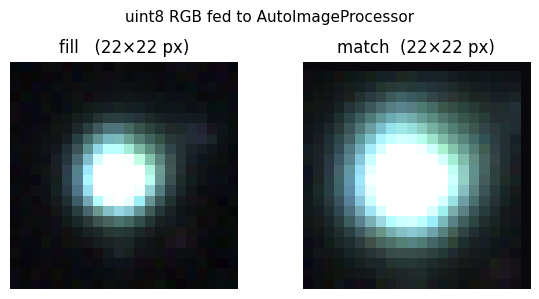

In [8]:
def to_uint8(a):
    return (a[..., ::-1] * 255).astype(np.uint8)

rgb_fill  = to_uint8(arr_fill_norm)    # (22, 22, 3)
rgb_match = to_uint8(arr_match_norm)   # (22, 22, 3)

fig, axs = plt.subplots(1, 2, figsize=(6, 3))
axs[0].imshow(rgb_fill,  origin="lower")
axs[0].set_title(f"fill   ({rgb_fill.shape[0]}×{rgb_fill.shape[1]} px)")
axs[0].axis("off")
axs[1].imshow(rgb_match, origin="lower")
axs[1].set_title(f"match  ({rgb_match.shape[0]}×{rgb_match.shape[1]} px)")
axs[1].axis("off")
plt.suptitle("uint8 RGB fed to AutoImageProcessor", fontsize=11)
plt.tight_layout()
plt.show()

## 6. `AutoImageProcessor`: resize to 224×224 and ImageNet normalise

The processor is model-specific, not survey-specific. For ConvNeXtV2 it resizes the image (regardless of its current size) to 224×224 with bicubic interpolation and then normalises with ImageNet mean/std. Both paths produce identically shaped tensors here.

In [9]:
MODEL_NAME = "facebook/convnextv2-nano-22k-224"
processor  = AutoImageProcessor.from_pretrained(MODEL_NAME)

pv_fill  = processor(rgb_fill,  return_tensors="pt")["pixel_values"]
pv_match = processor(rgb_match, return_tensors="pt")["pixel_values"]

print(f"fill  pixel_values : {pv_fill.shape}   range=[{pv_fill.min():.3f}, {pv_fill.max():.3f}]")
print(f"match pixel_values : {pv_match.shape}  range=[{pv_match.min():.3f}, {pv_match.max():.3f}]")
print()
print("Both 22×22 images reach the model as (1, 3, 224, 224) after the processor's resize+crop.")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


fill  pixel_values : torch.Size([1, 3, 224, 224])   range=[-2.084, 2.640]
match pixel_values : torch.Size([1, 3, 224, 224])  range=[-1.964, 2.640]

Both 22×22 images reach the model as (1, 3, 224, 224) after the processor's resize+crop.


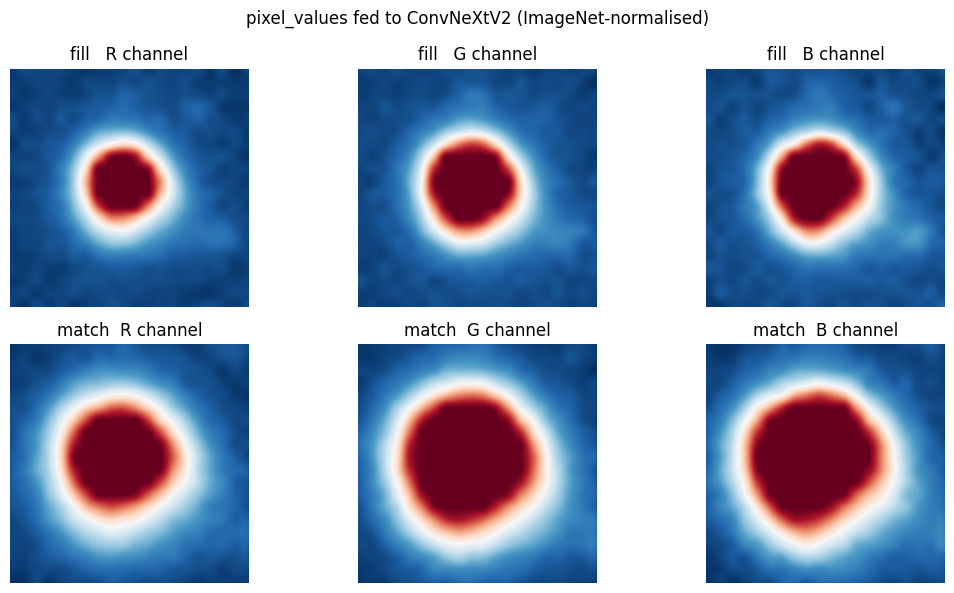

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(11, 6))
ch_labels = ["R channel", "G channel", "B channel"]
for col in range(3):
    axs[0, col].imshow(pv_fill[0, col].numpy(),  cmap="RdBu_r", origin="upper")
    axs[0, col].set_title(f"fill   {ch_labels[col]}")
    axs[0, col].axis("off")
    axs[1, col].imshow(pv_match[0, col].numpy(), cmap="RdBu_r", origin="upper")
    axs[1, col].set_title(f"match  {ch_labels[col]}")
    axs[1, col].axis("off")
plt.suptitle("pixel_values fed to ConvNeXtV2 (ImageNet-normalised)", fontsize=12)
plt.tight_layout()
plt.show()

## 7. ConvNeXtV2 forward pass

ConvNeXtV2 is fully convolutional — it preserves spatial structure. The final stage of `convnextv2-nano` produces a `(1, 640, 7, 7)` feature map regardless of which path was taken, because both inputs are `(1, 3, 224, 224)`.

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {device}")

model = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

with torch.no_grad():
    lhs_fill  = model(pv_fill.to(device)).last_hidden_state
    lhs_match = model(pv_match.to(device)).last_hidden_state

print(f"fill  last_hidden_state : {lhs_fill.shape}")
print(f"match last_hidden_state : {lhs_match.shape}")

Running on: cuda


Loading weights: 100%|██████████| 158/158 [00:00<00:00, 866.21it/s, Materializing param=layernorm.weight]                            
ConvNextV2Model LOAD REPORT from: facebook/convnextv2-nano-22k-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


fill  last_hidden_state : torch.Size([1, 640, 7, 7])
match last_hidden_state : torch.Size([1, 640, 7, 7])


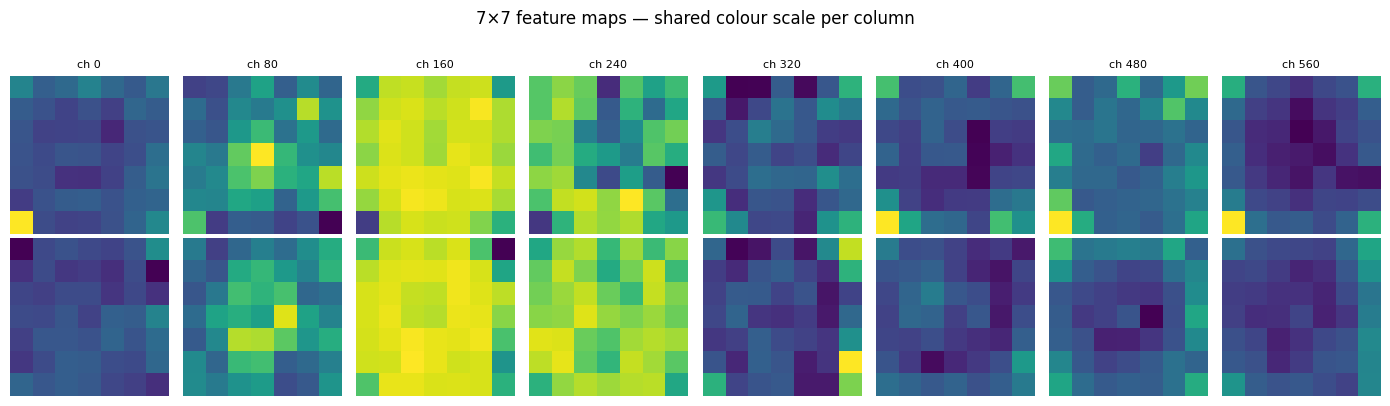

In [12]:
n_show = 8
fmaps_fill  = lhs_fill[0].cpu().numpy()
fmaps_match = lhs_match[0].cpu().numpy()

fig, axs = plt.subplots(2, n_show, figsize=(14, 4))
for i in range(n_show):
    ch   = i * 80
    vmin = min(fmaps_fill[ch].min(), fmaps_match[ch].min())
    vmax = max(fmaps_fill[ch].max(), fmaps_match[ch].max())
    axs[0, i].imshow(fmaps_fill[ch],  cmap="viridis", vmin=vmin, vmax=vmax)
    axs[0, i].set_title(f"ch {ch}", fontsize=8)
    axs[0, i].axis("off")
    if i == 0:
        axs[0, i].set_ylabel("fill", fontsize=8)
    axs[1, i].imshow(fmaps_match[ch], cmap="viridis", vmin=vmin, vmax=vmax)
    axs[1, i].axis("off")
    if i == 0:
        axs[1, i].set_ylabel("match", fontsize=8)
plt.suptitle("7×7 feature maps — shared colour scale per column", y=1.02)
plt.tight_layout()
plt.show()

## 8. Spatial mean pooling → embedding vectors

`HFAdapter.embed_for_mode()` averages over the 7×7 spatial grid: `outputs.mean(dim=(2, 3))`. This is applied identically to both paths.

In [13]:
emb_fill  = lhs_fill.mean(dim=(2, 3)).float()    # (1, 640)
emb_match = lhs_match.mean(dim=(2, 3)).float()

fill_np  = emb_fill[0].cpu().numpy()
match_np = emb_match[0].cpu().numpy()

cos_sim = F.cosine_similarity(emb_fill, emb_match).item()

print(f"fill  embedding shape : {emb_fill.shape}")
print(f"match embedding shape : {emb_match.shape}")
print()
print(f"Cosine similarity (fill vs match) : {cos_sim:.4f}")

fill  embedding shape : torch.Size([1, 640])
match embedding shape : torch.Size([1, 640])

Cosine similarity (fill vs match) : 0.8876


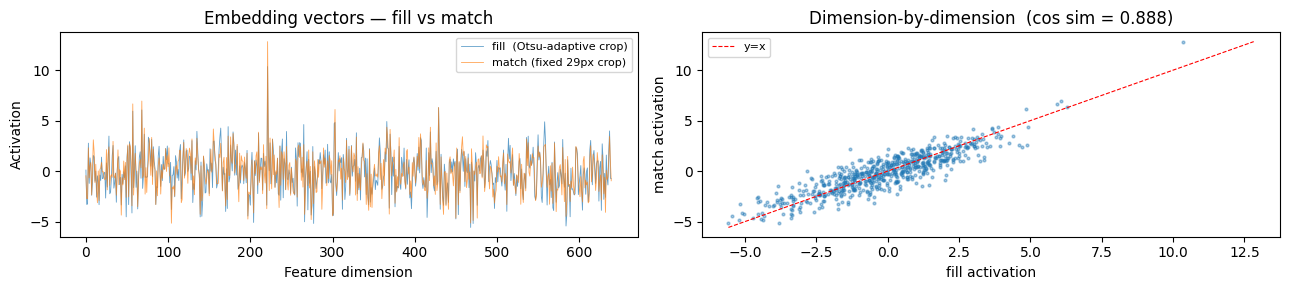

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(13, 3))

axs[0].plot(fill_np,  alpha=0.7, linewidth=0.6, label="fill  (Otsu-adaptive crop)")
axs[0].plot(match_np, alpha=0.7, linewidth=0.6, label="match (fixed 29px crop)")
axs[0].set_xlabel("Feature dimension")
axs[0].set_ylabel("Activation")
axs[0].set_title("Embedding vectors — fill vs match")
axs[0].legend(fontsize=8)

axs[1].scatter(fill_np, match_np, s=4, alpha=0.4)
lo = min(fill_np.min(), match_np.min())
hi = max(fill_np.max(), match_np.max())
axs[1].plot([lo, hi], [lo, hi], "r--", linewidth=0.8, label="y=x")
axs[1].set_xlabel("fill activation")
axs[1].set_ylabel("match activation")
axs[1].set_title(f"Dimension-by-dimension  (cos sim = {cos_sim:.3f})")
axs[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Summary

| Step | `fill` mode | `match` mode (default) |
|---|---|---|
| Raw flux | `(5, 160, 160)` float32 | `(5, 160, 160)` float32 |
| Channel selection | `(160, 160, 3)` | `(160, 160, 3)` |
| Crop determination | Otsu threshold → blob extent (adaptive) | fixed `force_extent=(68,92,68,92)` → 29px |
| After `resize_galaxy_to_fit` | `(22, 22, 3)` | `(22, 22, 3)` |
| Percentile norm | `(22, 22, 3)` ∈ [0,1] | `(22, 22, 3)` ∈ [0,1] |
| uint8 cast | `(22, 22, 3)` uint8 | `(22, 22, 3)` uint8 |
| `AutoImageProcessor` | `(1, 3, 224, 224)` | `(1, 3, 224, 224)` |
| ConvNeXtV2 | `(1, 640, 7, 7)` | `(1, 640, 7, 7)` |
| Mean pool | **(1, 640)** | **(1, 640)** |

Both modes produce the same shaped embedding. The difference is in what each 22×22 pixel image contains: `fill` frames the galaxy tightly based on its detected angular size; `match` always shows the same fixed angular footprint (~4.8 arcsec) calibrated to the JWST image scale.